# Is the published result correct? --- FEWS farm model

Jones (2022), *Environment Systems and Decisions*,
[10.1007/s10669-021-09838-8](https://doi.org/10.1007/s10669-021-09838-8).

**This notebook needs no solver and no licence.** It is this repository's central
claim, and it is deliberately kept apart from the notebook that demonstrates the
code: merging them would make checking the paper depend on being able to run it.

Re-solving and checking are different verbs, and checking is the stronger one.
Re-solving needs Gurobi, a licence, and the same version and hardware to land in
the same place. Checking needs arithmetic, and it reproduces bit for bit forever.

`01_example.ipynb` is the other one: it runs the model.

## 1. Install

On Colab, **clone the repository and install from that checkout.**
`pip install git+https://...` is not enough and fails in a way that looks like a
bug in the model: it installs the package but not `data/`, because the
precipitation inputs live in `data/raw/` and are not part of the wheel. The
installed `config.py` then derives the repository root relative to site-packages,
and the first cell that loads data dies with a `FileNotFoundError` naming a
directory that has nothing to do with the problem.

In [1]:
import subprocess
import sys

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO = "https://github.com/sear-labs/fews-stochopt-esd-2022.git"
    subprocess.run(["git", "clone", "--depth", "1", REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "fews-stochopt-esd-2022"], check=True)
    print("cloned and installed from the checkout")
else:
    print("running from a local checkout; `pip install -e .` once if you have not")

import fews_stochopt

print("fews_stochopt", fews_stochopt.__version__)

running from a local checkout; `pip install -e .` once if you have not
fews_stochopt 1.0.0


## 2. Check twelve frozen models against their solutions

`artifacts/` ships each collapsed instance and its solution. For every one,
`scripts/verify_solution.py` confirms that the point satisfies every constraint
and bound, that recomputing the objective from the variable values gives the
number this repository reports, and how far an independent search can improve on
it.

It imports neither `gurobipy` nor `fews_stochopt`: it writes the model out again
from the shipped instance files, because a check written from the same source as
the thing it checks is not a check.

In [2]:
import pathlib

import fews_stochopt

# Derived from the INSTALLED package, never from the working directory. A
# relative "../scripts/..." breaks the moment the notebook runs from anywhere but
# its own folder, which is exactly what happens on Colab after the clone.
ROOT = pathlib.Path(fews_stochopt.__file__).resolve().parents[2]


def run_script(name, *args):
    """Run a repository script and show BOTH streams and the return code.

    Printing only stdout is how a failing script comes to look like one that did
    nothing.
    """
    proc = subprocess.run(
        [sys.executable, str(ROOT / "scripts" / name), *args],
        capture_output=True, text=True, cwd=str(ROOT),
    )
    if proc.stdout:
        print(proc.stdout.rstrip())
    if proc.stderr:
        print("--- stderr ---")
        print(proc.stderr.rstrip())
    if proc.returncode != 0:
        raise RuntimeError(f"{name} exited {proc.returncode}")
    # Return the code, not the CompletedProcess. Its repr carries `args`, which
    # is the interpreter path and the absolute script path -- so a cell ending
    # in this call committed one machine's home directory into the notebook.
    return proc.returncode


run_script("verify_solution.py")

Verifying 12 model(s) from artifacts, with no solver and no licence.

  DML_expected_value
    5 weighted blocks, 4,000 runs, 35 variables   (first stage fixed)
    recomputed objective   1,898,261.671957
    claimed in .sol        1,898,261.671957   (delta 0.000e+00)
    worst row violation    0.000e+00
    worst bound violation  0.000e+00
    best independent search1,898,261.679250   (shipped value is +0.0073 from it)
    FEASIBLE, objective confirmed, and optimal to within $0.0073
  DML_known_climate_unknown_weather_climate1
    4 weighted blocks, 2,400 runs, 30 variables
    recomputed objective   1,648,352.523588
    claimed in .sol        1,648,352.523588   (delta 0.000e+00)
    worst row violation    0.000e+00
    worst bound violation  0.000e+00
    best independent search1,648,352.604741   (shipped value is +0.0812 from it)
    FEASIBLE, objective confirmed, and optimal to within $0.0812
  DML_known_climate_unknown_weather_climate2
    5 weighted blocks, 1,000 runs, 37 variabl

0

The last figure on each line is small and **positive by design**.
Gurobi returns points a little *outside* the feasible region while reporting
`OPTIMAL`, so every shipped solution is clipped back inside before it is stored.
The reported values are therefore valid lower bounds, and the true optimum sits
just above them.

## 3. The reproduced table against the paper

`results/clean/value_of_information.csv` is committed, so this needs no run.

In [3]:
import pandas as pd

values = pd.read_csv(ROOT / "results" / "clean" / "value_of_information.csv")
short = {"Value_of_Known_Weather": "EVKW", "Value_of_Known_Climate": "EVKC",
         "Value_of_Perfect_Information": "EVPI",
         "Value_of_Stochastic_Solution": "VSS"}
table = values.assign(quantity=values["variable"].map(short))[
    ["label", "quantity", "published", "value", "difference"]]
# Rendered through HTML() with a fixed uuid so the committed output is
# byte-reproducible. A bare Styler emits two machine-dependent tokens: a
# `<Styler at 0x...>` repr in text/plain, and a random table id throughout the
# HTML. Both are inert, and a comparison taught to ignore them would also be
# ignoring the table itself -- which is exactly what happened here once.
from IPython.display import HTML

styled = table.style.format({"published": "{:,.4f}", "value": "{:,.4f}",
                             "difference": "{:+.4f}"}).set_uuid("voi")
display(HTML(styled.to_html()))

worst = table["difference"].abs().max()
print(f"largest difference: ${worst:,.4f}")
print("The Dry Most Likely VSS is the known one: its first stage solves a")
print("problem whose objective is flat. See docs/reproduction-notes.md, section 3.")

,label,quantity,published,value,difference
0,Equally Probable,EVKW,"10,396.3181","10,395.2685",-1.0496
1,Equally Probable,EVPI,"108,725.1417","108,724.4843",-0.6574
2,Equally Probable,VSS,0.4887,0.3413,-0.1474
3,Equally Probable,EVKC,"98,328.8236","98,329.2158",+0.3922
4,Dry Most Likely,EVKW,"11,740.0306","11,739.3104",-0.7201
5,Dry Most Likely,EVPI,"76,606.0081","76,605.5746",-0.4335
6,Dry Most Likely,VSS,940.8999,964.8863,+23.9864
7,Dry Most Likely,EVKC,"64,865.9775","64,866.2642",+0.2867


largest difference: $23.9864
The Dry Most Likely VSS is the known one: its first stage solves a
problem whose objective is flat. See docs/reproduction-notes.md, section 3.


## 4. What the figures show

Regenerated by `scripts/make_figures.py` from cleaned output, never from the raw
solver dump. Each carries a text alternative in `figures/generated/README.md`.

value_of_information.png


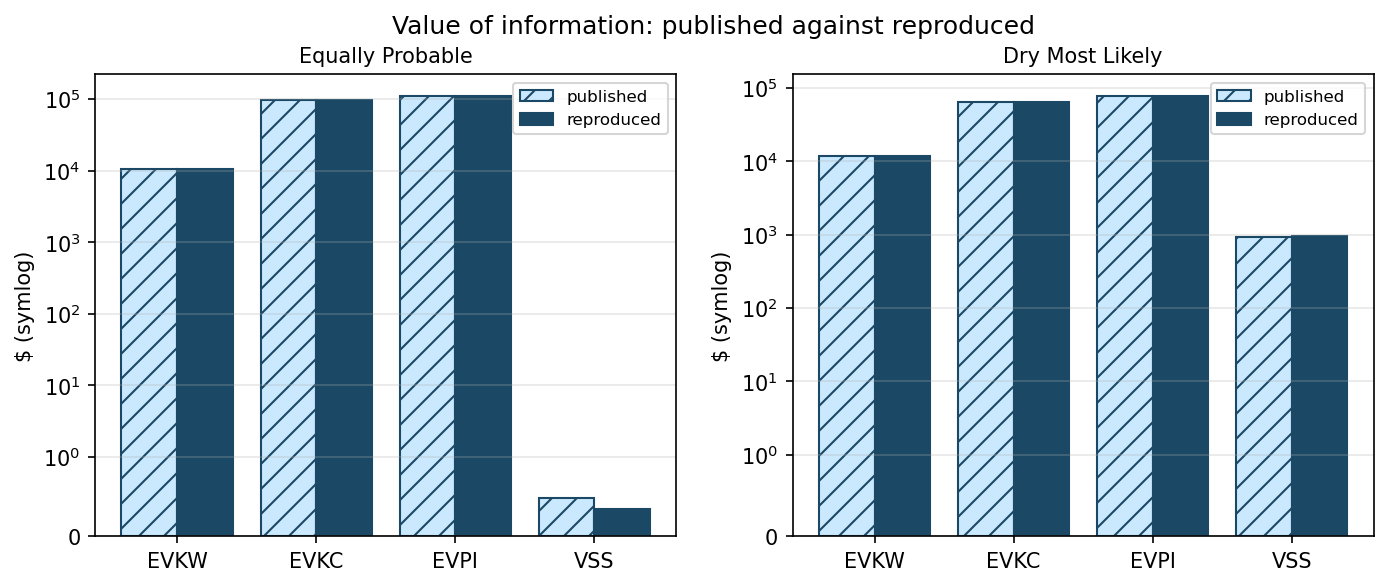

profit_against_rainfall.png


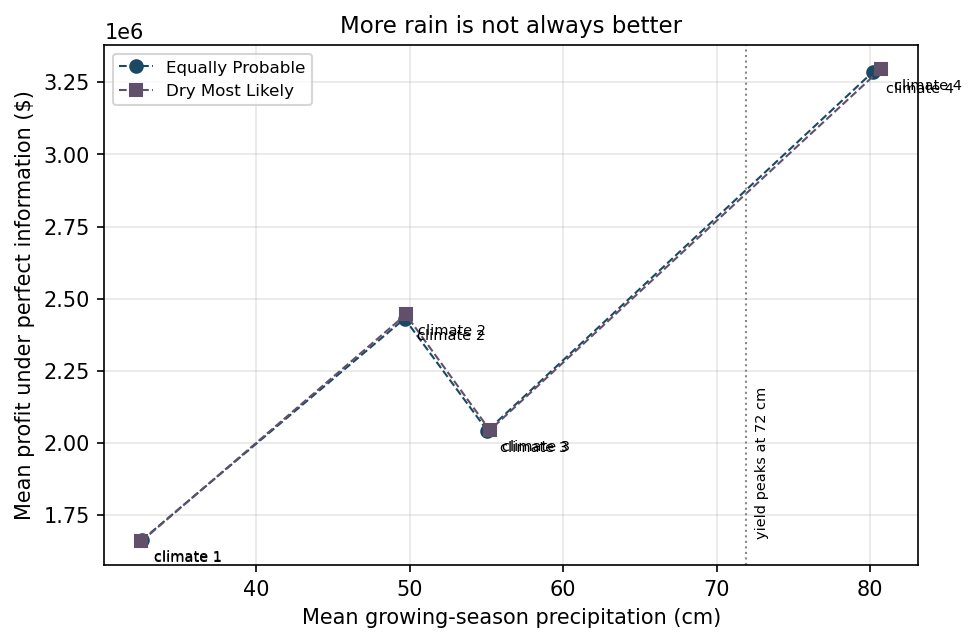

In [4]:
from IPython.display import Image, display as show

for name in ("value_of_information.png", "profit_against_rainfall.png"):
    print(name)
    show(Image(filename=str(ROOT / "figures" / "generated" / name)))